In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

In [3]:
url = 'https://raw.githubusercontent.com/AarohiSingla/SVM/main/Social_Network_Ads.csv'
df = pd.read_csv(url)
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
...,...,...,...,...,...
395,15691863,Female,46,41000,1
396,15706071,Male,51,23000,1
397,15654296,Female,50,20000,1
398,15755018,Male,36,33000,0


In [9]:
df.corr()['Purchased']

C:\Users\Lim Otto\AppData\Local\Temp\ipykernel_3876\2318995518.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Purchased']


User ID            0.007120
Age                0.622454
EstimatedSalary    0.362083
Purchased          1.000000
Name: Purchased, dtype: float64

In [21]:
#Assigning X and y variable
X = df.iloc[:,[2,3]] #Exclude userID, Gender
y = df.iloc[:, -1]

In [22]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64

In [23]:
#Splitting X and y to training sets & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state=0)

In [24]:
#Scaling X variable
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.fit_transform(X_test)


In [26]:
#Building SVM model w/linear kernel
from sklearn.svm import SVC
model_linear = SVC(kernel = 'linear', random_state = 0)
model_linear.fit(X_train, y_train)
y_pred_linear = model_linear.predict(X_test)

In [29]:
from sklearn import metrics
print('Accuracy of linear model', metrics.accuracy_score(y_test, y_pred_linear))

Accuracy of linear model 0.88


In [31]:
#Building SVM model w/rbf kernel
from sklearn.svm import SVC
model_rbf = SVC(kernel = 'rbf')
model_rbf.fit(X_train, y_train)
y_pred_rbf = model_rbf.predict(X_test)
print('Accuracy of rbf model', metrics.accuracy_score(y_test, y_pred_rbf))

Accuracy of rbf model 0.93


In [40]:
#Building SVM model w/polynomial kernel
model_poly = SVC(kernel = 'poly', degree = 3)
model_poly.fit(X_train, y_train)
y_pred_poly = model_poly.predict(X_test)
print('Accuracy of poly model', metrics.accuracy_score(y_test, y_pred_poly))

Accuracy of poly model 0.84


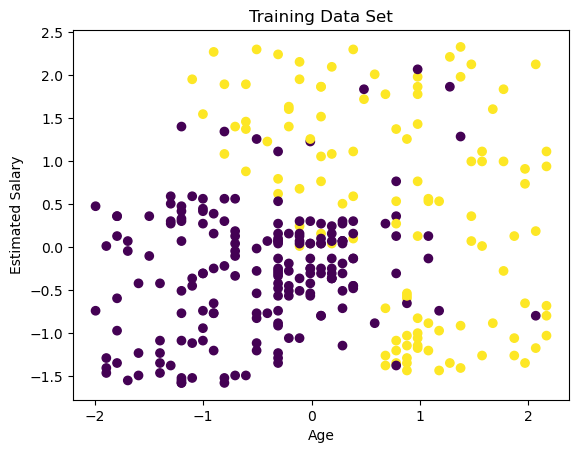

In [42]:
#Visualize the training data to show non-linear relationship
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.title('Training Data Set')
plt.show()


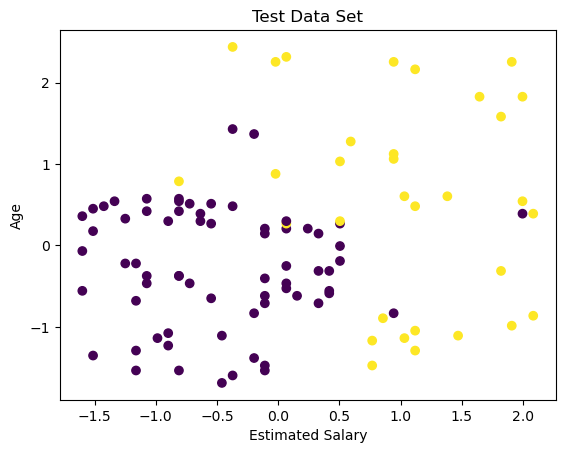

In [43]:
#Plotting the test data set
plt.scatter(X_test[:, 0], X_test[:, -1], c=y_test)
plt.ylabel('Age')
plt.xlabel('Estimated Salary')
plt.title('Test Data Set')
plt.show()

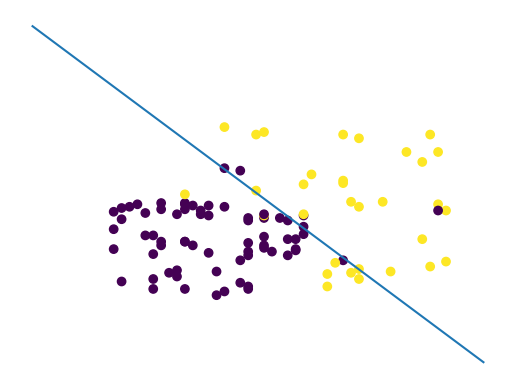

In [49]:
#Drawing the hyperplane on test data set
plt.scatter(X_test[:, 0], X_test[:, -1], c=y_test)

w = model_linear.coef_[0]
a = -w[0] / w[1]
xx = np.linspace(-2.5, 2.5)
yy = a * xx - (model_linear.intercept_[0]) / w[1]

plt.plot(xx, yy)
plt.axis("off")
plt.show()

In [ ]:
#Conclusion, visualized scatter plot shows non-linear relationship
#Hence linear model unable to produce the best results
#RBF is used is particularly effective in classification tasks where the relationship between the features and the target variable is non-linear.